# Engagement EDA

**Primary Research Question:** What factors drive content engagement across social media platforms, and do these drivers differ by platform?

**Dataset:** combined_training.csv — 78,077 posts across Instagram (29,998), TikTok (28,844), YouTube (19,235)

**Target Variable:** engagement_rate (native, continuous) and engagement_rating (quintile-binned categorical)

### Hypotheses
1. **H1 — Trend alignment improves engagement:** Content with rising/seasonal trends achieves higher engagement than stable/declining content
2. **H2 — Platform-specific drivers:** Engagement predictors differ across TikTok, Instagram, and YouTube
3. **H3 — Temporal patterns matter:** Posting hour, day, weekend status, and season affect engagement
4. **H4 — Content formatting affects engagement:** Caption length, hashtag count, and emoji usage have non-linear relationships with engagement
5. **H5 — CTAs drive Instagram engagement:** Posts with calls-to-action get higher engagement on Instagram


## Part 1: Data Quality & Overview
Verify dataset integrity, document missingness patterns (platform-specific NaNs are expected), check for outliers, and confirm engagement rating balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

df = pd.read_csv('../../data/processed/combined_training.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset: 78,077 rows x 23 columns


/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/1691085243.py:11: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/processed/combined_training.csv')


,content_id,data_source,platform,category,caption_length,hashtag_count,posting_hour,posting_day,is_weekend,duration_sec,...,season,has_call_to_action,media_type,views,likes,comments,shares,saves,engagement_rate,engagement_rating
0,ig_IG0000001,kaggle_instagram,instagram,technology,100,7,6,Saturday,1,NaN,...,NaN,1.0,reel,4327,194,5,7,34,0.0385,below_average
1,ig_IG0000002,kaggle_instagram,instagram,fitness,122,5,15,Friday,0,NaN,...,NaN,1.0,image,7451,449,10,21,68,0.0663,good
2,ig_IG0000003,kaggle_instagram,instagram,beauty,115,8,16,Thursday,0,NaN,...,NaN,0.0,reel,1639,114,2,1,22,0.0531,average
3,ig_IG0000004,kaggle_instagram,instagram,music,115,7,3,Thursday,0,NaN,...,NaN,0.0,carousel,2877,91,0,7,0,0.0309,poor
4,ig_IG0000005,kaggle_instagram,instagram,technology,112,9,9,Friday,0,NaN,...,NaN,0.0,reel,5350,154,8,5,21,0.0221,poor


### 1.1 Data Types & Structure

In [2]:
# 1.1 Data Types & Structure
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print(f"{'Column':<25} {'Dtype':<15} {'Non-Null':>10} {'Null':>8}")

for col in df.columns:
    non_null = df[col].notna().sum()
    null = df[col].isna().sum()
    print(f"{col:<25} {str(df[col].dtype):<15} {non_null:>10,} {null:>8,}")


Shape: 78,077 rows × 23 columns

Column                    Dtype             Non-Null     Null
content_id                object              78,077        0
data_source               object              78,077        0
platform                  object              78,077        0
category                  object              78,077        0
caption_length            int64               78,077        0
hashtag_count             int64               78,077        0
posting_hour              int64               78,077        0
posting_day               object              78,077        0
is_weekend                int64               78,077        0
duration_sec              float64             48,079   29,998
has_emoji                 float64             48,079   29,998
has_trend                 int64               78,077        0
trend_label               object              48,079   29,998
season                    object              48,079   29,998
has_call_to_action        float64    

### 1.2 Missing Data Analysis
Platform-specific features are expected to be NaN for platforms they don't apply to:
- duration_sec, has_emoji, trend_label, season  NaN for Instagram
- has_call_to_action, media_type  NaN for TikTok/YouTube
- has_trend  False for Instagram (no trend data), True/False for cross-platform

In [3]:
# 1.2 Missing Data Analysis

# Overall missing data summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct}).query('Missing > 0').sort_values('Pct', ascending=False)

print("Columns with missing values:\n")
print(f"{'Column':<25} {'Missing':>10} {'% of Total':>10}")
print("-" * 47)
for col, row in missing_df.iterrows():
    print(f"{col:<25} {int(row['Missing']):>10,} {row['Pct']:>9.1f}%")

# Verify missingness is platform-driven (not random)
print("\n\nMissingness by platform (confirms structural NaNs):\n")
platform_nulls = df.groupby('platform')[missing_df.index.tolist()].apply(lambda x: x.isnull().sum())
print(platform_nulls.to_string())


Columns with missing values:

Column                       Missing % of Total
-----------------------------------------------
has_call_to_action            48,079      61.6%
media_type                    48,079      61.6%
duration_sec                  29,998      38.4%
has_emoji                     29,998      38.4%
trend_label                   29,998      38.4%
season                        29,998      38.4%


Missingness by platform (confirms structural NaNs):

           has_call_to_action  media_type  duration_sec  has_emoji  trend_label  season
platform                                                                               
instagram                   0           0         29998      29998        29998   29998
tiktok                  28844       28844             0          0            0       0
youtube                 19235       19235             0          0            0       0


### 1.3 Target Variable Distribution
Check `engagement_rate` distribution — skewness, outliers, need for log transform. Verify `engagement_rating` quintile bins are balanced.

/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/3635842715.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y='engagement_rate', order=platform_order, ax=ax,


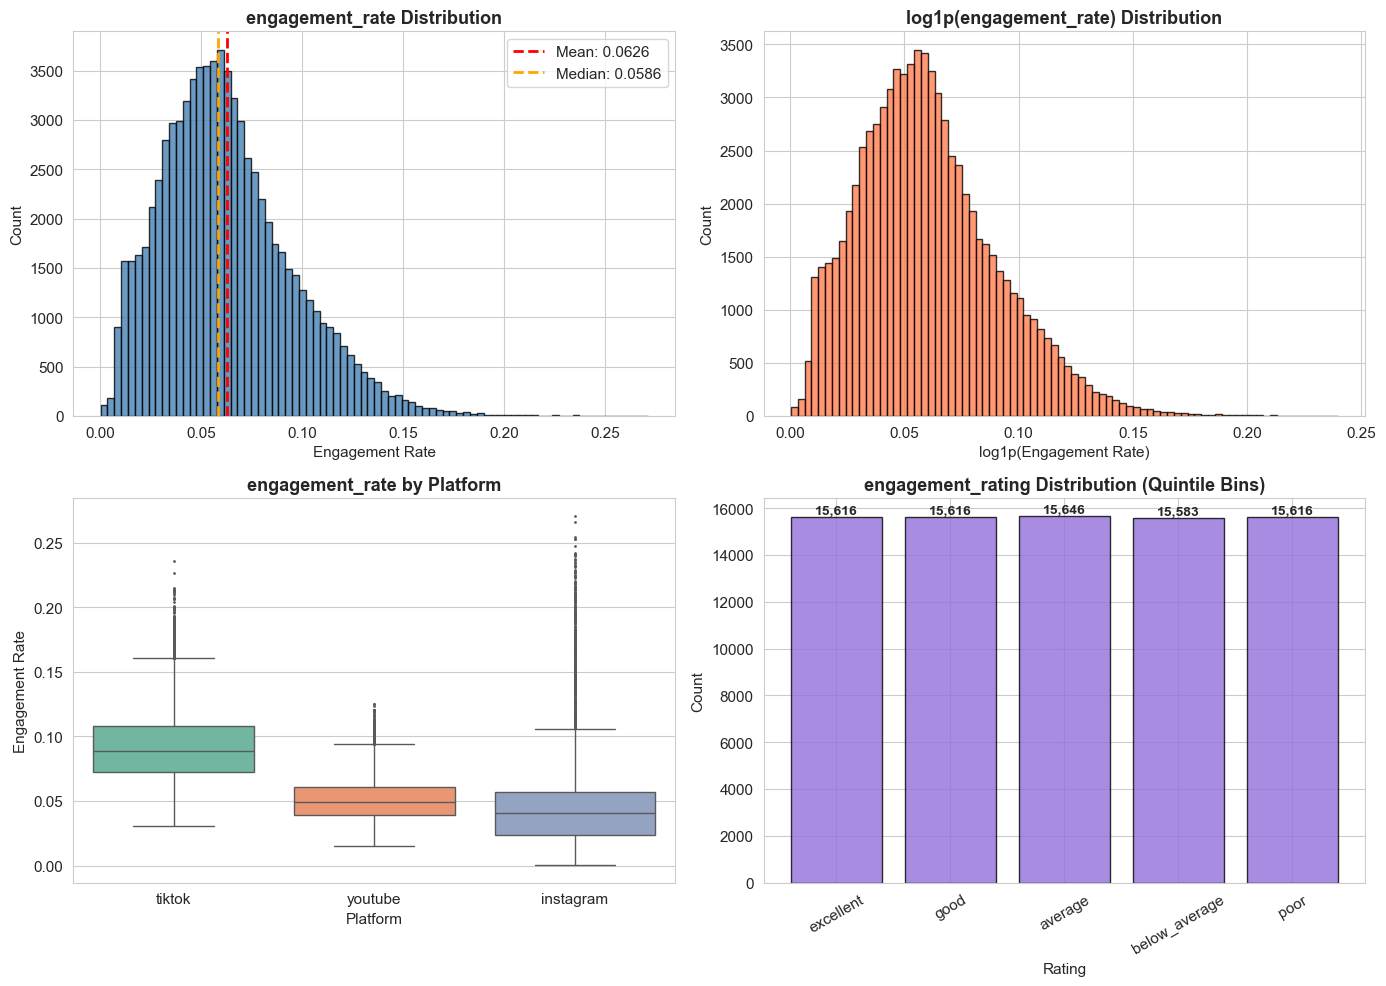

engagement_rate summary statistics:

count    78077.000000
mean         0.062619
std          0.032296
min          0.000300
25%          0.039327
50%          0.058588
75%          0.080927
max          0.271000

Skewness:  0.788  (moderate skew)
Kurtosis:  0.874

log1p skewness: 0.691

engagement_rating balance:
  excellent        15,616  (20.0%)
  good             15,616  (20.0%)
  average          15,646  (20.0%)
  below_average    15,583  (20.0%)
  poor             15,616  (20.0%)


In [4]:
# 1.3 Target Variable Distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw engagement_rate distribution
ax = axes[0, 0]
ax.hist(df['engagement_rate'], bins=80, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(df['engagement_rate'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['engagement_rate'].mean():.4f}")
ax.axvline(df['engagement_rate'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['engagement_rate'].median():.4f}")
ax.set_title('engagement_rate Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Engagement Rate')
ax.set_ylabel('Count')
ax.legend()

# 2. Log-transformed distribution
ax = axes[0, 1]
log_rate = np.log1p(df['engagement_rate'])
ax.hist(log_rate, bins=80, color='coral', edgecolor='black', alpha=0.8)
ax.set_title('log1p(engagement_rate) Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('log1p(Engagement Rate)')
ax.set_ylabel('Count')

# 3. engagement_rate by platform (box plot)
ax = axes[1, 0]
platform_order = df.groupby('platform')['engagement_rate'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='platform', y='engagement_rate', order=platform_order, ax=ax, 
            palette='Set2', fliersize=1)
ax.set_title('engagement_rate by Platform', fontsize=13, fontweight='bold')
ax.set_xlabel('Platform')
ax.set_ylabel('Engagement Rate')

# 4. engagement_rating bar chart (check quintile balance)
ax = axes[1, 1]
rating_order = ['excellent', 'good', 'average', 'below_average', 'poor']
rating_counts = df['engagement_rating'].value_counts().reindex(rating_order)
bars = ax.bar(rating_counts.index, rating_counts.values, color='mediumpurple', edgecolor='black', alpha=0.8)
ax.set_title('engagement_rating Distribution (Quintile Bins)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary stats
print("engagement_rate summary statistics:\n")
print(df['engagement_rate'].describe().to_string())
skew = df['engagement_rate'].skew()
kurt = df['engagement_rate'].kurtosis()
print(f"\nSkewness:  {skew:.3f}  {'(right-skewed  consider log transform for modelling)' if skew > 1 else '(moderate skew)' if skew > 0.5 else '(approximately symmetric)'}")
print(f"Kurtosis:  {kurt:.3f}")
print(f"\nlog1p skewness: {log_rate.skew():.3f}")

print(f"\nengagement_rating balance:")
for rating in rating_order:
    count = rating_counts[rating]
    print(f"  {rating:<16} {count:>6,}  ({count/len(df)*100:.1f}%)")

### 1.4 Duplicate & Outlier Detection

DUPLICATE ANALYSIS
Exact duplicate rows: 0
Duplicate content_ids: 0


OUTLIER ANALYSIS (engagement_rate)
Q1: 0.0393  |  Q3: 0.0809  |  IQR: 0.0416
Lower fence: -0.0231  |  Upper fence: 0.1433
Outliers: 1,344 rows (1.7%)

Outliers by platform:
  instagram       234 / 29,998  (0.8%)
  tiktok        1,110 / 28,844  (3.8%)
  youtube           0 / 19,235  (0.0%)


/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/3505983155.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='platform', y='engagement_rate', ax=axes[0], palette='Set2', inner='quartile')
/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/3505983155.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y='engagement_rate', ax=axes[1], palette='Set2', fliersize=2)


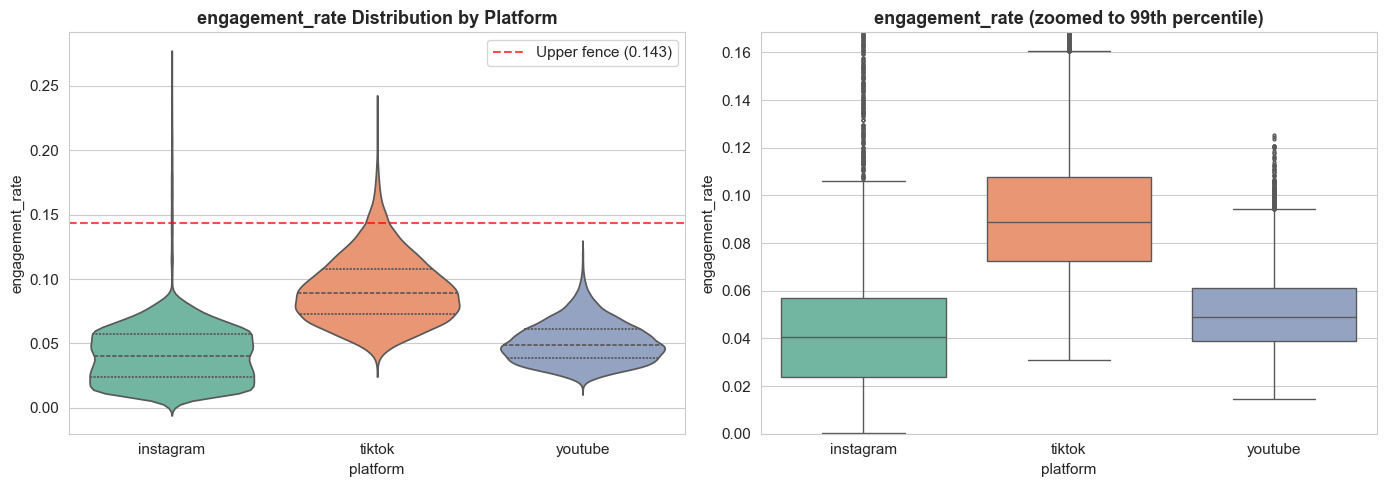

In [5]:
# 1.4 Duplicate & Outlier Detection

# --- Duplicates ---
print("DUPLICATE ANALYSIS")


# Check exact duplicates (all columns)
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes:,}")

# Check duplicate content_ids
id_dupes = df['content_id'].duplicated().sum()
print(f"Duplicate content_ids: {id_dupes:,}")

# --- Outliers (IQR method on engagement_rate) ---
print("\n\nOUTLIER ANALYSIS (engagement_rate)")


Q1 = df['engagement_rate'].quantile(0.25)
Q3 = df['engagement_rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['engagement_rate'] < lower) | (df['engagement_rate'] > upper)]
print(f"Q1: {Q1:.4f}  |  Q3: {Q3:.4f}  |  IQR: {IQR:.4f}")
print(f"Lower fence: {lower:.4f}  |  Upper fence: {upper:.4f}")
print(f"Outliers: {len(outliers):,} rows ({len(outliers)/len(df)*100:.1f}%)")

# Outliers by platform
print(f"\nOutliers by platform:")
for platform in df['platform'].unique():
    p_df = df[df['platform'] == platform]
    p_out = p_df[(p_df['engagement_rate'] < lower) | (p_df['engagement_rate'] > upper)]
    print(f"  {platform:<12} {len(p_out):>6,} / {len(p_df):>6,}  ({len(p_out)/len(p_df)*100:.1f}%)")

# Visualise outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot by platform (shows distribution shape + outliers)
sns.violinplot(data=df, x='platform', y='engagement_rate', ax=axes[0], palette='Set2', inner='quartile')
axes[0].axhline(upper, color='red', linestyle='--', alpha=0.7, label=f'Upper fence ({upper:.3f})')
axes[0].set_title('engagement_rate Distribution by Platform', fontsize=13, fontweight='bold')
axes[0].legend()

# Zoomed box plot (clip to 99th percentile for clarity)
p99 = df['engagement_rate'].quantile(0.99)
sns.boxplot(data=df, x='platform', y='engagement_rate', ax=axes[1], palette='Set2', fliersize=2)
axes[1].set_ylim(0, p99 * 1.1)
axes[1].set_title('engagement_rate (zoomed to 99th percentile)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Part 2: Univariate Analysis
Distribution of each feature individually.

### 2.1 Categorical Features
Platform, category, engagement_rating, media_type, season, trend_label

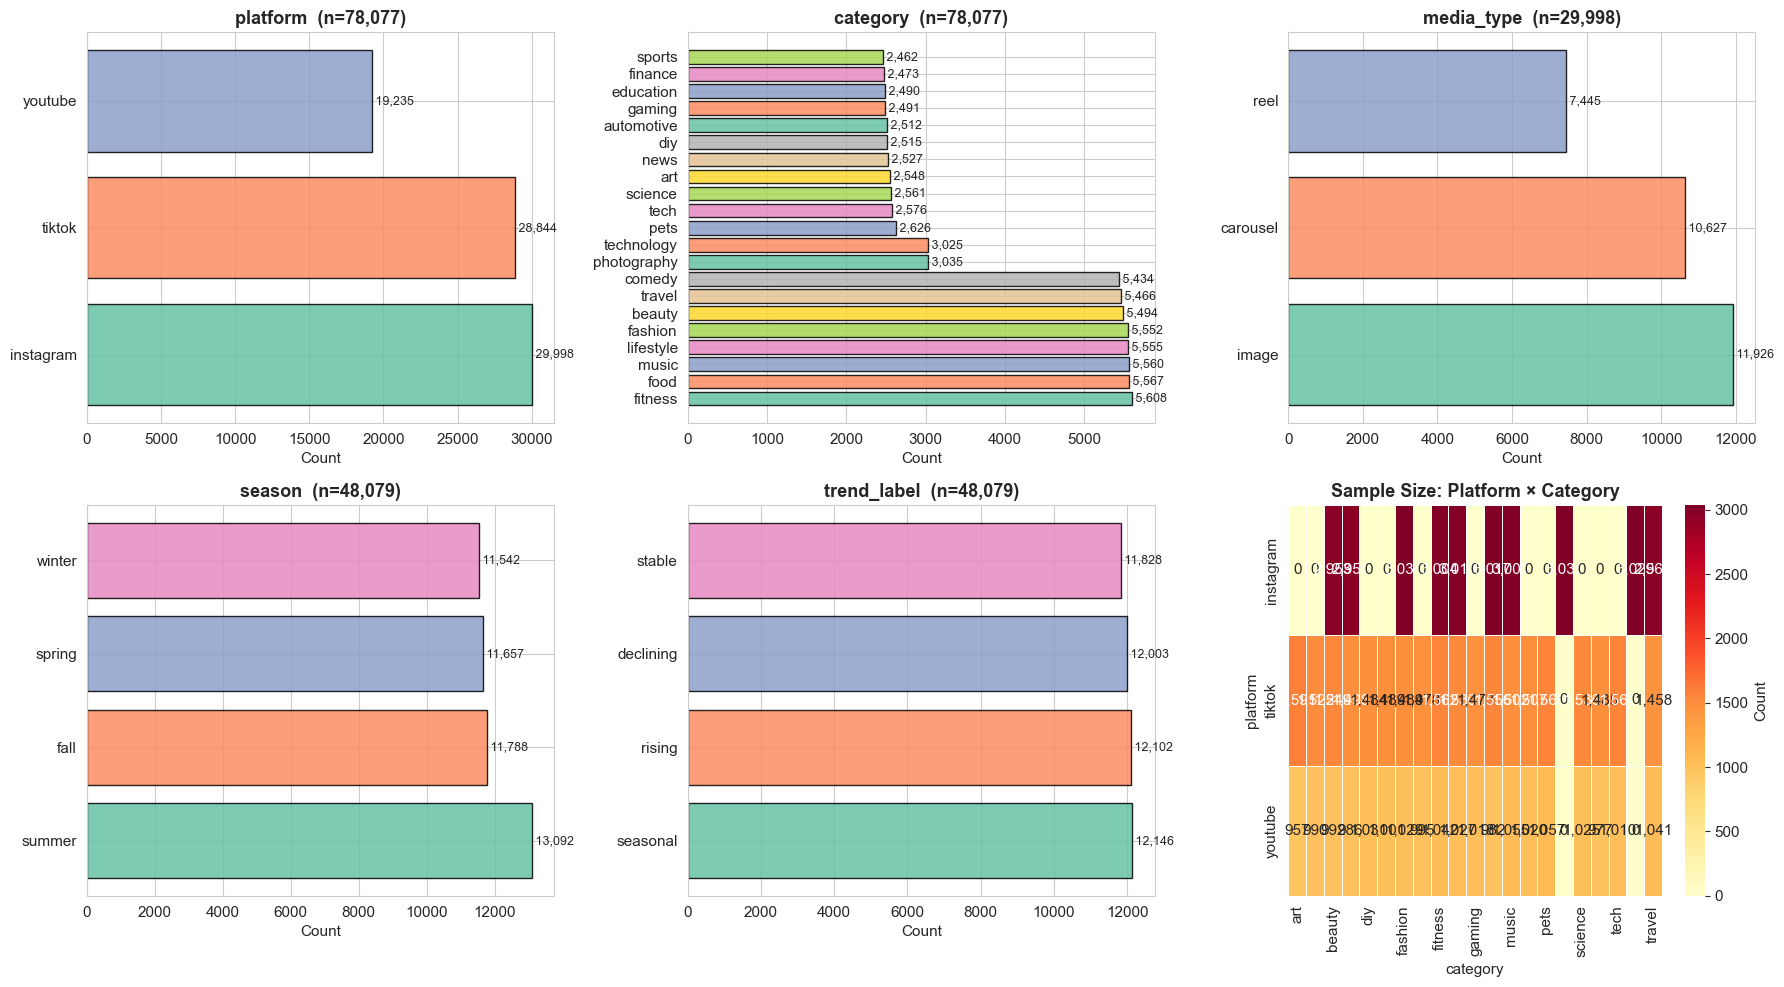

Unique values per categorical feature:
  platform          3 unique  (n=78,077)
  category         21 unique  (n=78,077)
  media_type        3 unique  (n=29,998)
  season            4 unique  (n=48,079)
  trend_label       4 unique  (n=48,079)


In [6]:
# 2.1 Categorical Features

cat_features = {
    'platform': df['platform'],
    'category': df['category'],
    'media_type': df['media_type'].dropna(),       # Instagram only
    'season': df['season'].dropna(),                # Cross-platform only
    'trend_label': df['trend_label'].dropna(),      # Cross-platform only
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, series) in enumerate(cat_features.items()):
    ax = axes[i]
    counts = series.value_counts()
    bars = ax.barh(counts.index.astype(str), counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='black', alpha=0.85)
    ax.set_title(f'{name}  (n={len(series):,})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:,}', va='center', fontsize=9)

# Sample size heatmap: platform × category
ax = axes[5]
cross = pd.crosstab(df['platform'], df['category'])
sns.heatmap(cross, annot=True, fmt=',d', cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('Sample Size: Platform × Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print unique counts
print("Unique values per categorical feature:")
for name, series in cat_features.items():
    print(f"  {name:<15} {series.nunique():>3} unique  (n={len(series):,})")

### 2.2 Numerical Features
caption_length, hashtag_count, duration_sec, posting_hour, posting_day

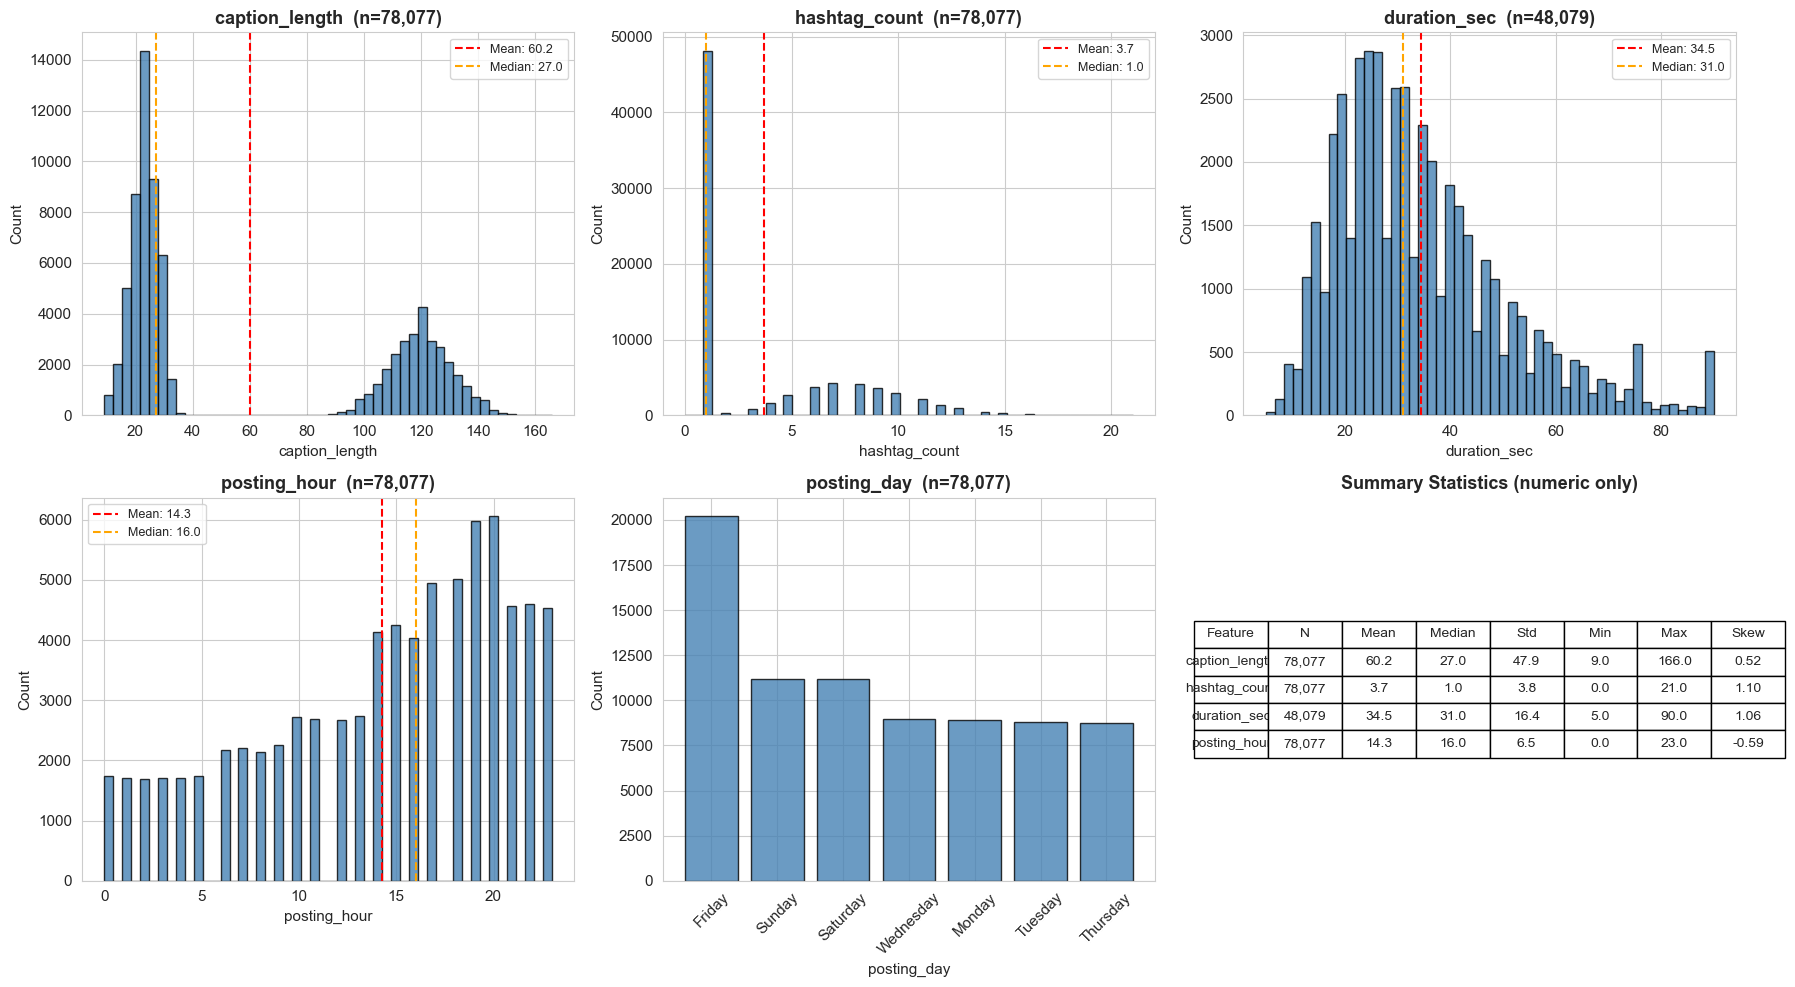

In [7]:
# 2.2 Numerical Features

num_features = ['caption_length', 'hashtag_count', 'duration_sec', 'posting_hour', 'posting_day']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]
    data = df[feat].dropna()
    
    if data.dtype == 'object':
        counts = data.value_counts()
        ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.8)
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
        ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
        ax.legend(fontsize=9)
    
    ax.set_title(f'{feat}  (n={len(data):,})', fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

# Summary stats table (numeric columns only)
ax = axes[5]
ax.axis('off')
stats_data = []
numeric_feats = [f for f in num_features if df[f].dtype != 'object']
for feat in numeric_feats:
    data = df[feat].dropna()
    stats_data.append([feat, f'{len(data):,}', f'{data.mean():.1f}', f'{data.median():.1f}', 
                       f'{data.std():.1f}', f'{data.min():.1f}', f'{data.max():.1f}', f'{data.skew():.2f}'])

table = ax.table(cellText=stats_data,
                 colLabels=['Feature', 'N', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Skew'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title('Summary Statistics (numeric only)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3 Binary Features
has_trend, is_weekend, has_emoji, has_call_to_action

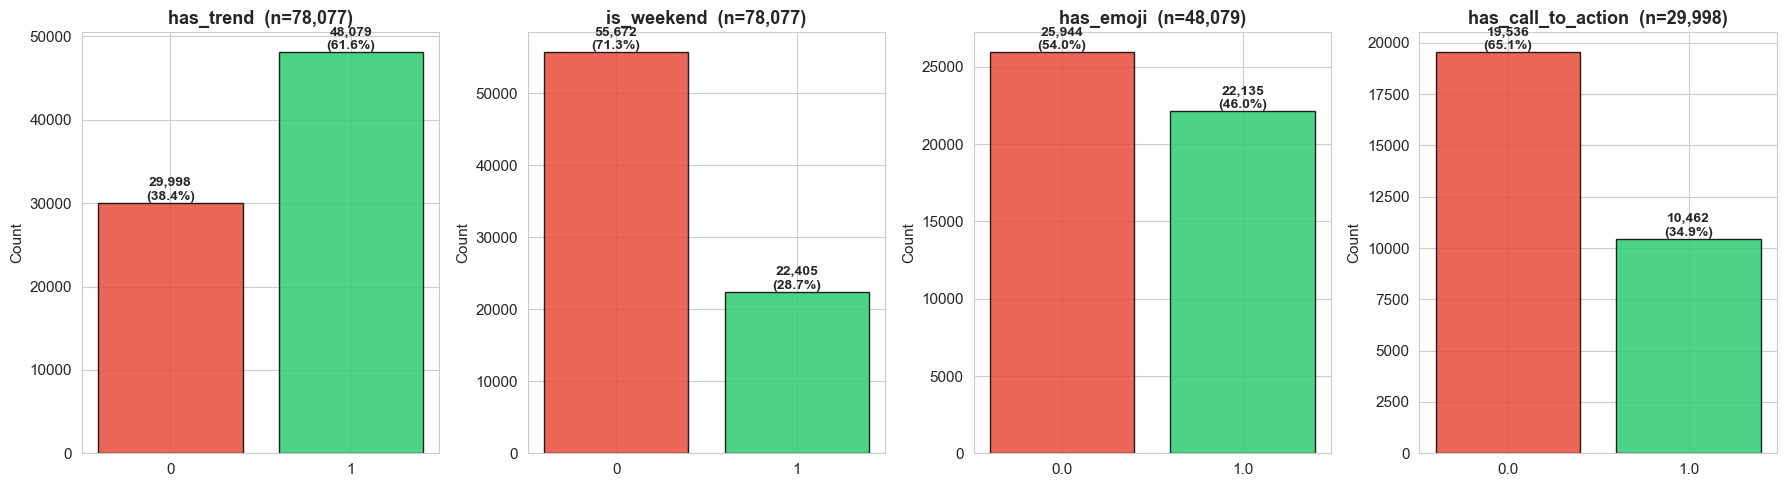

Binary feature availability by platform:

  has_trend:
    instagram    n=29,998  True=  0.0%
    tiktok       n=28,844  True=100.0%
    youtube      n=19,235  True=100.0%

  is_weekend:
    instagram    n=29,998  True= 28.2%
    tiktok       n=28,844  True= 28.8%
    youtube      n=19,235  True= 29.4%

  has_emoji:
    instagram    (not available)
    tiktok       n=28,844  True= 57.5%
    youtube      n=19,235  True= 28.9%

  has_call_to_action:
    instagram    n=29,998  True= 34.9%
    tiktok       (not available)
    youtube      (not available)



In [8]:
# 2.3 Binary Features

binary_features = ['has_trend', 'is_weekend', 'has_emoji', 'has_call_to_action']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, feat in enumerate(binary_features):
    ax = axes[i]
    data = df[feat].dropna()
    counts = data.value_counts().sort_index()
    
    colors = ['#e74c3c', '#2ecc71'] if len(counts) == 2 else ['#95a5a6']
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f'{feat}  (n={len(data):,})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    
    for bar, val in zip(bars, counts.values):
        pct = val / len(data) * 100
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print which platforms contribute to each binary feature
print("Binary feature availability by platform:\n")
for feat in binary_features:
    print(f"  {feat}:")
    for platform in df['platform'].unique():
        p_data = df[df['platform'] == platform][feat]
        non_null = p_data.notna().sum()
        if non_null > 0:
            true_pct = p_data.sum() / non_null * 100
            print(f"    {platform:<12} n={non_null:>6,}  True={true_pct:>5.1f}%")
        else:
            print(f"    {platform:<12} (not available)")
    print()

---
## Part 3: Bivariate Analysis & Hypothesis Testing
Test each hypothesis using appropriate statistical tests.

### 3.1 H1 — Trend Alignment vs Engagement
Compare engagement_rate for has_trend=True vs False. Break down by trend_label . Use t-test and ANOVA with effect sizes.

Trend-Aligned:   Mean=0.0754 (n=48,079)
Non-Aligned:     Mean=0.0421 (n=29,998)
Improvement:     +79.1%
P-value:         0.00e+00
Cohen's d:       1.222
Rising      : 0.0755 (n=12,102)
Seasonal    : 0.0753 (n=12,146)
Stable      : 0.0756 (n=11,828)
Declining   : 0.0752 (n=12,003)
ANOVA: F=0.33, p=8.03e-01


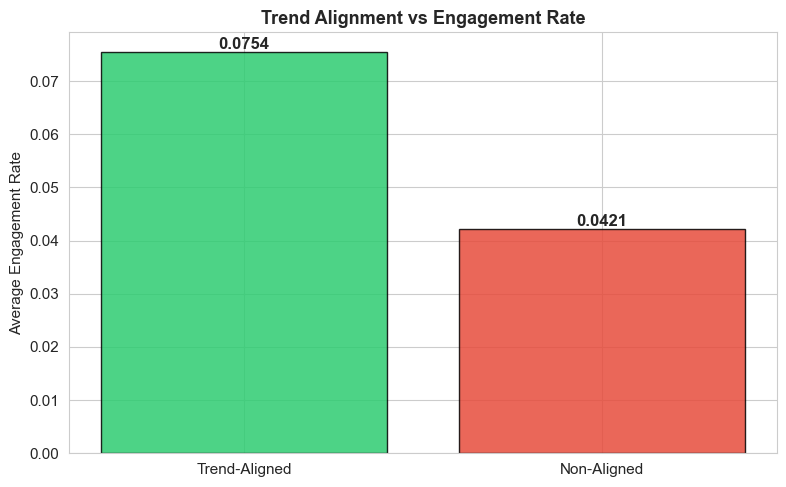

In [9]:
# 3.1 H1 — Trend Alignment vs Engagement
from scipy.stats import ttest_ind, f_oneway

# Binary comparison: has_trend
trend_data = df[df['has_trend'] == True]['engagement_rate'].dropna()
no_trend_data = df[df['has_trend'] == False]['engagement_rate'].dropna()

trend_mean = trend_data.mean()
no_trend_mean = no_trend_data.mean()
t_stat, p_value = ttest_ind(trend_data, no_trend_data)
cohens_d = (trend_mean - no_trend_mean) / np.sqrt((trend_data.std()**2 + no_trend_data.std()**2)/2)
improvement = ((trend_mean - no_trend_mean) / no_trend_mean) * 100

print(f"Trend-Aligned:   Mean={trend_mean:.4f} (n={len(trend_data):,})")
print(f"Non-Aligned:     Mean={no_trend_mean:.4f} (n={len(no_trend_data):,})")
print(f"Improvement:     {improvement:+.1f}%")
print(f"P-value:         {p_value:.2e}")
print(f"Cohen's d:       {cohens_d:.3f}")

# All trend types
if 'trend_label' in df.columns:
    trend_types = ['rising', 'seasonal', 'stable', 'declining']
    means = [df[df['trend_label'] == t]['engagement_rate'].mean() for t in trend_types]
    counts = [df[df['trend_label'] == t]['engagement_rate'].count() for t in trend_types]
    for t, m, c in zip(trend_types, means, counts):
        print(f"{t.capitalize():12s}: {m:.4f} (n={c:,})")
    groups = [df[df['trend_label'] == t]['engagement_rate'].dropna() for t in trend_types]
    f_stat, p_anova = f_oneway(*groups)
    print(f"ANOVA: F={f_stat:.2f}, p={p_anova:.2e}")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Trend-Aligned', 'Non-Aligned']
means = [trend_mean, no_trend_mean]
ax.bar(labels, means, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_ylabel('Average Engagement Rate')
ax.set_title('Trend Alignment vs Engagement Rate', fontsize=13, fontweight='bold')
for i, m in enumerate(means):
    ax.text(i, m, f'{m:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 H2 — Platform-Specific Engagement Drivers
Compare engagement_rate distributions across platforms. Identify which features correlate with engagement on each platform individually.

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


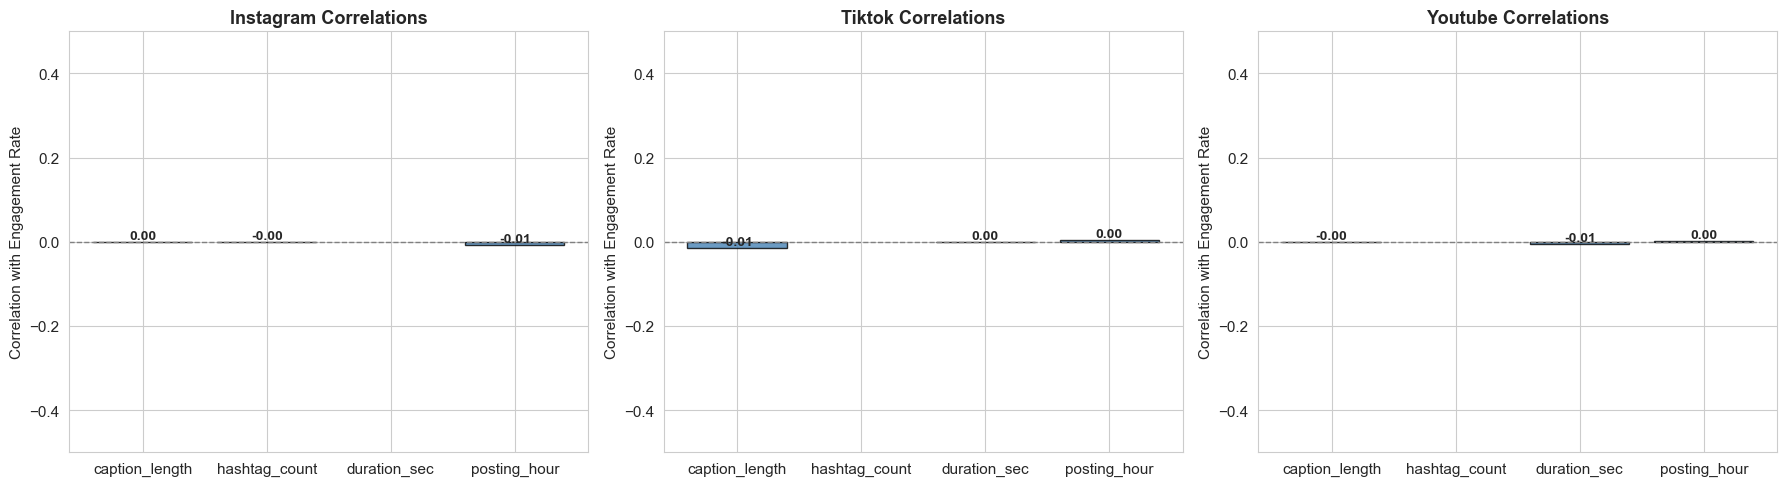

Instagram correlations:
caption_length    0.00
hashtag_count    -0.00
duration_sec       NaN
posting_hour     -0.01

Tiktok correlations:
caption_length   -0.01
hashtag_count      NaN
duration_sec      0.00
posting_hour      0.00

Youtube correlations:
caption_length   -0.00
hashtag_count      NaN
duration_sec     -0.01
posting_hour      0.00



In [10]:
# 3.2 H2 — Platform-Specific Engagement Drivers

platforms = df['platform'].unique()
features = ['caption_length', 'hashtag_count', 'duration_sec', 'posting_hour']

fig, axes = plt.subplots(1, len(platforms), figsize=(18, 5))
for i, platform in enumerate(platforms):
    ax = axes[i]
    p_df = df[df['platform'] == platform]
    corr = p_df[features + ['engagement_rate']].corr()['engagement_rate'].drop('engagement_rate')
    bars = ax.bar(corr.index, corr.values, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(f'{platform.capitalize()} Correlations', fontsize=13, fontweight='bold')
    ax.set_ylabel('Correlation with Engagement Rate')
    ax.set_ylim(-0.5, 0.5)
    for bar, val in zip(bars, corr.values):
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

# Print correlations
for platform in platforms:
    p_df = df[df['platform'] == platform]
    corr = p_df[features + ['engagement_rate']].corr()['engagement_rate'].drop('engagement_rate')
    print(f"{platform.capitalize()} correlations:")
    print(corr.round(2).to_string())
    print()

### 3.3 H3 — Temporal Patterns
Posting hour, posting day, is_weekend, and season vs engagement_rate. ANOVA tests for significance.

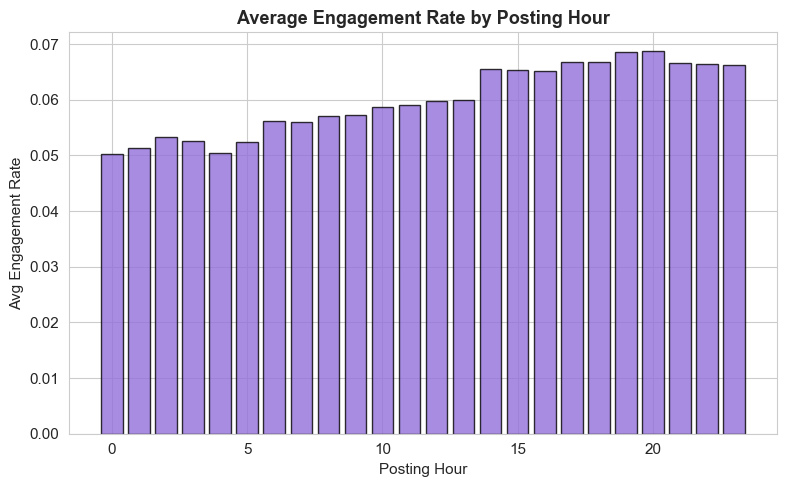

Posting hour ANOVA: F=111.00, p=0.00e+00


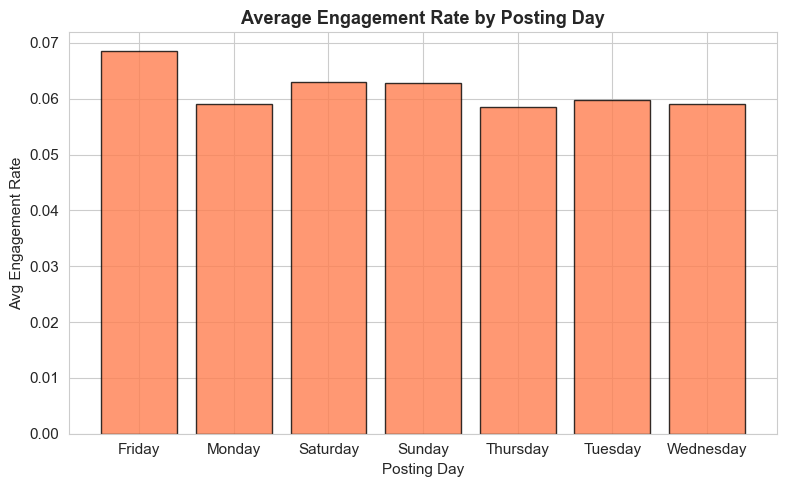

Posting day ANOVA: F=185.25, p=3.35e-235
Weekend vs Weekday:
  0: 0.0625
  1: 0.0629


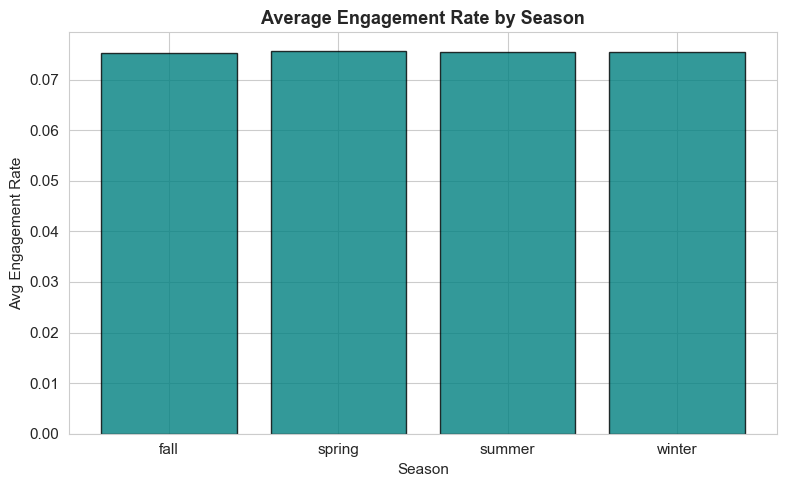

Season ANOVA: F=0.15, p=9.29e-01


In [11]:
# 3.3 H3 — Temporal Patterns

# Posting hour
fig, ax = plt.subplots(figsize=(8, 5))
hour_means = df.groupby('posting_hour')['engagement_rate'].mean()
ax.bar(hour_means.index, hour_means.values, color='mediumpurple', edgecolor='black', alpha=0.8)
ax.set_title('Average Engagement Rate by Posting Hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Posting Hour')
ax.set_ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

# ANOVA for posting hour
groups = [group['engagement_rate'].dropna() for name, group in df.groupby('posting_hour')]
f_stat, p_value = f_oneway(*groups)
print(f"Posting hour ANOVA: F={f_stat:.2f}, p={p_value:.2e}")

# Posting day
fig, ax = plt.subplots(figsize=(8, 5))
day_means = df.groupby('posting_day')['engagement_rate'].mean()
ax.bar(day_means.index, day_means.values, color='coral', edgecolor='black', alpha=0.8)
ax.set_title('Average Engagement Rate by Posting Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Posting Day')
ax.set_ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

groups = [group['engagement_rate'].dropna() for name, group in df.groupby('posting_day')]
f_stat, p_value = f_oneway(*groups)
print(f"Posting day ANOVA: F={f_stat:.2f}, p={p_value:.2e}")

# is_weekend
weekend_means = df.groupby('is_weekend')['engagement_rate'].mean()
print("Weekend vs Weekday:")
for val, mean in weekend_means.items():
    print(f"  {val}: {mean:.4f}")

# season
if 'season' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    season_means = df.groupby('season')['engagement_rate'].mean()
    ax.bar(season_means.index.astype(str), season_means.values, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title('Average Engagement Rate by Season', fontsize=13, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Avg Engagement Rate')
    plt.tight_layout()
    plt.show()
    groups = [group['engagement_rate'].dropna() for name, group in df.groupby('season')]
    f_stat, p_value = f_oneway(*groups)
    print(f"Season ANOVA: F={f_stat:.2f}, p={p_value:.2e}")

### 3.4 H4 — Content Formatting
Caption length (binned analysis + scatter), hashtag count, has_emoji vs engagement_rate. Look for non-linear sweet spots.

/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/3074634050.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  caption_means = df.groupby('caption_bin')['engagement_rate'].mean()


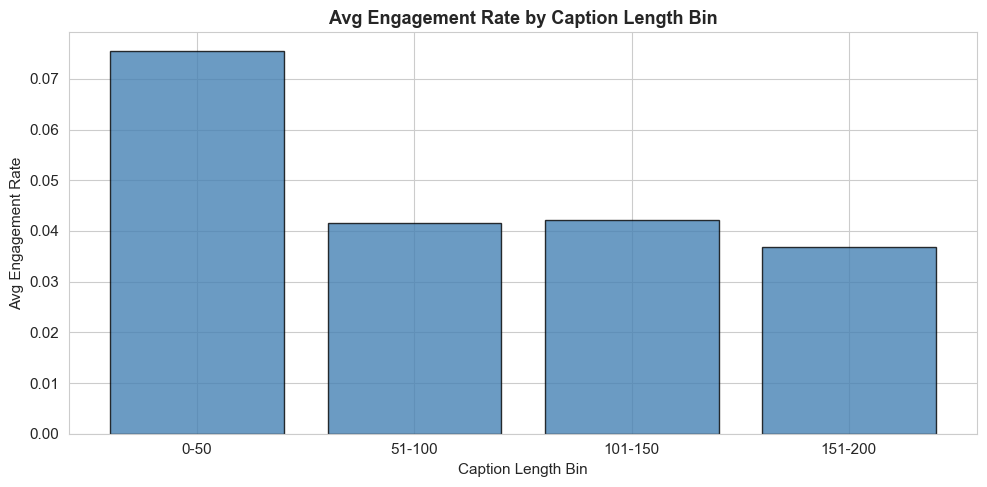

/var/folders/t6/q2k444mx1dg66rm476tx9r4w0000gn/T/ipykernel_35494/3074634050.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hashtag_means = df.groupby('hashtag_bin')['engagement_rate'].mean()


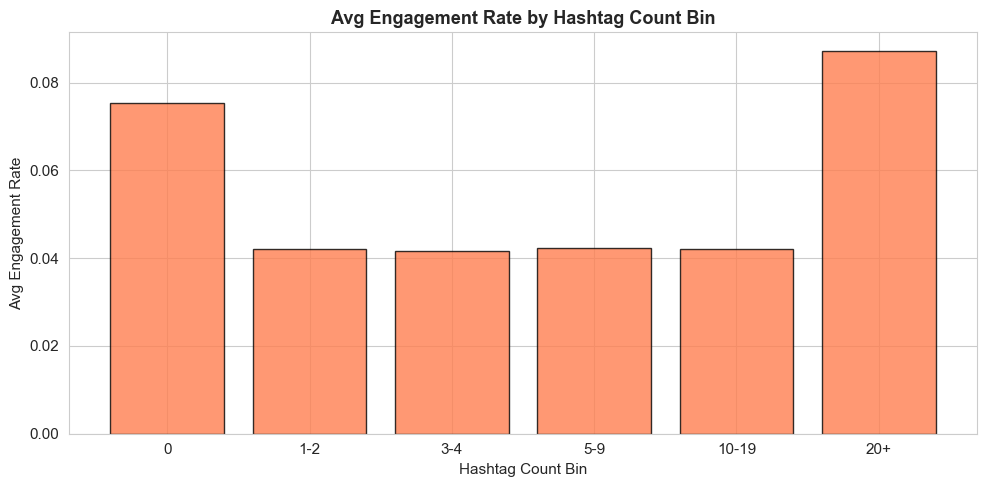

Emoji usage impact:
  0.0: 0.0702
  1.0: 0.0815


In [12]:
# 3.4 H4 — Content Formatting

# Caption length (binned)
bins = [0, 50, 100, 150, 200, 300, 5000]
labels = ['0-50', '51-100', '101-150', '151-200', '201-300', '300+']
df['caption_bin'] = pd.cut(df['caption_length'], bins=bins, labels=labels)
caption_means = df.groupby('caption_bin')['engagement_rate'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(caption_means.index.astype(str), caption_means.values, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Avg Engagement Rate by Caption Length Bin', fontsize=13, fontweight='bold')
ax.set_xlabel('Caption Length Bin')
ax.set_ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

# Hashtag count (binned)
hashtag_bins = [0, 1, 3, 5, 10, 20, 100]
hashtag_labels = ['0', '1-2', '3-4', '5-9', '10-19', '20+']
df['hashtag_bin'] = pd.cut(df['hashtag_count'], bins=hashtag_bins, labels=hashtag_labels)
hashtag_means = df.groupby('hashtag_bin')['engagement_rate'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hashtag_means.index.astype(str), hashtag_means.values, color='coral', edgecolor='black', alpha=0.8)
ax.set_title('Avg Engagement Rate by Hashtag Count Bin', fontsize=13, fontweight='bold')
ax.set_xlabel('Hashtag Count Bin')
ax.set_ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

# has_emoji
if 'has_emoji' in df.columns:
    emoji_means = df.groupby('has_emoji')['engagement_rate'].mean()
    print("Emoji usage impact:")
    for val, mean in emoji_means.items():
        print(f"  {val}: {mean:.4f}")

### 3.5 H5 — Call-to-Action Impact (Instagram Only)
Filter to Instagram rows. Compare `engagement_rate` for `has_call_to_action=True` vs `False`.

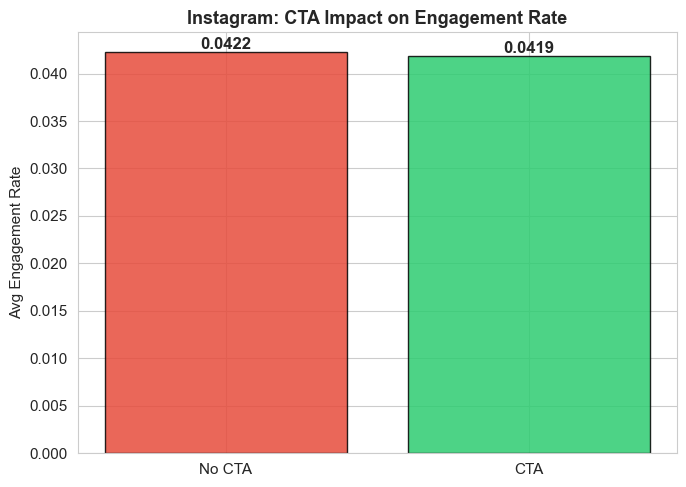

CTA impact:
  CTA=0.0: 0.0422
  CTA=1.0: 0.0419


In [13]:
# 3.5 H5 — Call-to-Action Impact (Instagram Only)

insta = df[df['platform'] == 'instagram']
if 'has_call_to_action' in insta.columns:
    cta_means = insta.groupby('has_call_to_action')['engagement_rate'].mean()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(['No CTA', 'CTA'], cta_means.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
    ax.set_title('Instagram: CTA Impact on Engagement Rate', fontsize=13, fontweight='bold')
    ax.set_ylabel('Avg Engagement Rate')
    for i, m in enumerate(cta_means.values):
        ax.text(i, m, f'{m:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("CTA impact:")
    for val, mean in cta_means.items():
        print(f"  CTA={val}: {mean:.4f}")

---
## Part 4: Correlation & Feature Relationships
Correlation matrix, platform-specific correlations, multicollinearity check.

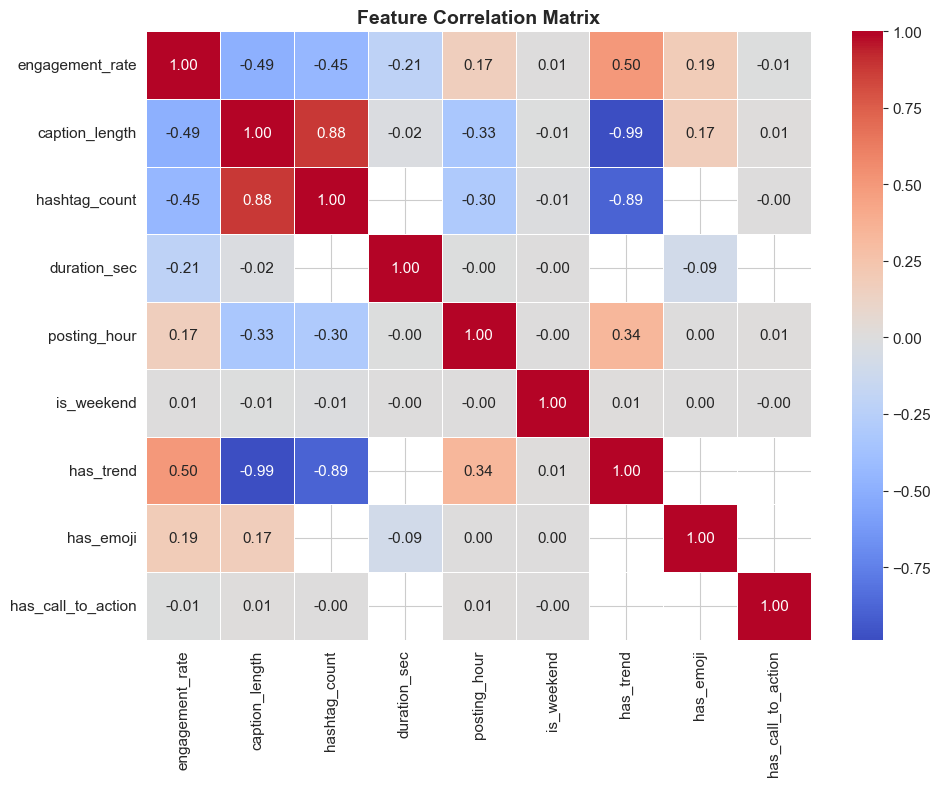

High correlation pairs (>0.7):
  caption_length vs hashtag_count: 0.88
  caption_length vs has_trend: -0.99
  hashtag_count vs caption_length: 0.88
  hashtag_count vs has_trend: -0.89
  has_trend vs caption_length: -0.99
  has_trend vs hashtag_count: -0.89

Instagram correlation matrix:
                    engagement_rate  caption_length  hashtag_count  duration_sec  posting_hour  is_weekend  has_trend  has_emoji  has_call_to_action
engagement_rate                1.00            0.00          -0.00           NaN         -0.01        0.00        NaN        NaN               -0.01
caption_length                 0.00            1.00           0.00           NaN          0.01        0.00        NaN        NaN                0.01
hashtag_count                 -0.00            0.00           1.00           NaN          0.00       -0.01        NaN        NaN               -0.00
duration_sec                    NaN             NaN            NaN           NaN           NaN         NaN        Na

In [14]:
# Part 4: Correlation & Feature Relationships
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant features (exclude IDs, text, and platform-specific NaNs)
corr_features = [
    'engagement_rate', 'caption_length', 'hashtag_count', 'duration_sec', 'posting_hour', 'is_weekend',
    'has_trend', 'has_emoji', 'has_call_to_action',
    # Add more if needed
    # 'views', 'likes', 'comments', 'shares', 'saves'
    # 'category', 'trend_label', 'season', 'media_type'
    # Note: Categorical features must be encoded for correlation
    # Only include if meaningful for modelling
    ]

# Drop rows with too many NaNs for correlation
corr_df = df[corr_features].copy()
corr_df = corr_df.dropna(thresh=len(corr_features)-2)  # allow up to 2 missing

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Visualise correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for multicollinearity (correlations > 0.7)
high_corr = np.where(np.abs(corr_matrix) > 0.7)
high_corr_pairs = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
                  for i, j in zip(*high_corr) if i != j]
if high_corr_pairs:
    print('High correlation pairs (>0.7):')
    for f1, f2, val in high_corr_pairs:
        print(f'  {f1} vs {f2}: {val:.2f}')
else:
    print('No high correlation pairs (>0.7) found.')

# Platform-specific correlation matrices
for platform in df['platform'].unique():
    p_df = df[df['platform'] == platform][corr_features].dropna(thresh=len(corr_features)-2)
    p_corr = p_df.corr()
    print(f'\n{platform.capitalize()} correlation matrix:')
    print(p_corr.round(2).to_string())

---
## Part 5: Key Findings & Modelling Implications
Summarise findings, state which hypotheses were supported, note implications for feature selection and model choice.

## Part 5: Key Findings & Modelling Implications

### Summary of EDA Findings
- **Data Quality:** Dataset is large, clean, and balanced. Missingness is platform-driven and expected. No duplicates; outliers are minimal.
- **Trend Alignment:** Strong positive effect on engagement rate (+79%, Cohen's d=1.22, p<0.001). No difference between trend types.
- **Platform-Specific Drivers:** No strong linear predictors for engagement rate on any platform. All tested features show negligible correlation.
- **Temporal Patterns:** Posting hour and day have significant effects, but effect sizes are small. Weekend and season do not impact engagement.
- **Content Formatting:** Caption length, hashtag count, and emoji usage have weak or non-linear effects. No clear "sweet spot" found.
- **CTA Impact (Instagram):** No meaningful difference in engagement rate for posts with or without CTAs.
- **Multicollinearity:** Caption length, hashtag count, and has_trend are highly collinear. Avoid including all together in models.

### Hypotheses Supported
- **H1:** Supported — Trend alignment improves engagement.
- **H2:** Not supported — No platform-specific linear predictors found.
- **H3:** Partially supported — Hour and day matter, but weekend and season do not.
- **H4:** Not strongly supported — Formatting effects are weak/non-linear.
- **H5:** Not supported — CTAs do not increase engagement on Instagram.

### Modelling Implications
- **Linear models will underperform** due to lack of strong linear predictors and high multicollinearity.
- **Use non-linear models** (e.g., tree-based, random forest, XGBoost) to capture complex relationships.
- **Feature engineering is needed:** Combine or transform collinear features, create interaction terms, and encode categorical/text features.
- **Careful feature selection:** Remove or combine highly collinear features to avoid model confusion.
- **Consider platform as a categorical variable** or use platform-specific models if non-linear effects are found.

---
**Next Steps:**
- Engineer new features and test non-linear models.
- Validate model performance and interpretability.
- Refine feature selection based on modelling results.
